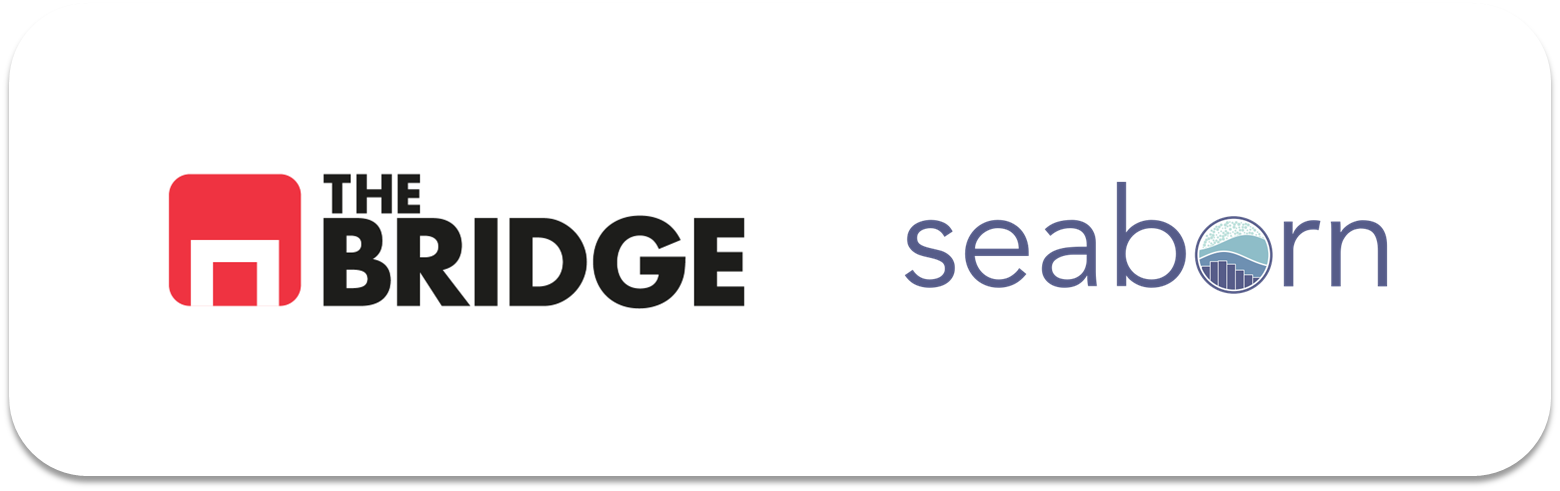

## PRACTICA OBLIGATORIA: **Visualización y Presentación**

* La práctica obligatoria de esta unidad se divide en dos partes, una dedicada a visualización y construcción de funciones, y la otra a hacer una presentación de resultados. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [6]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

DATA_DIR = Path("data")
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

## #1 VISUALIZACION

### #1.1

Carga el dataset de las ciudades de California que está en la ruta "./data/california_cities.csv". Muestra su contenido, deshazte de las filas con nulos.

In [7]:
california_path = DATA_DIR / "california_cities.csv"

cities = pd.read_csv(california_path)
print(f"Dimensiones originales: {cities.shape[0]} filas x {cities.shape[1]} columnas")
display(cities.head())

cities = cities.dropna().copy()
print(f"Dimensiones tras eliminar nulos: {cities.shape[0]} filas x {cities.shape[1]} columnas")
display(cities.head())

cities.info()

Dimensiones originales: 482 filas x 14 columnas


,Unnamed: 0,city,latd,longd,elevation_m,elevation_ft,population_total,area_total_sq_mi,area_land_sq_mi,area_water_sq_mi,area_total_km2,area_land_km2,area_water_km2,area_water_percent
0,0,Adelanto,34.576111,-117.432778,875.0,2871.0,31765,56.027,56.009,0.018,145.107,145.062,0.046,0.03
1,1,AgouraHills,34.153333,-118.761667,281.0,922.0,20330,7.822,7.793,0.029,20.260,20.184,0.076,0.37
2,2,Alameda,37.756111,-122.274444,NaN,33.0,75467,22.960,10.611,12.349,59.465,27.482,31.983,53.79
3,3,Albany,37.886944,-122.297778,NaN,43.0,18969,5.465,1.788,3.677,14.155,4.632,9.524,67.28
4,4,Alhambra,34.081944,-118.135000,150.0,492.0,83089,7.632,7.631,0.001,19.766,19.763,0.003,0.01


Dimensiones tras eliminar nulos: 427 filas x 14 columnas


,Unnamed: 0,city,latd,longd,elevation_m,elevation_ft,population_total,area_total_sq_mi,area_land_sq_mi,area_water_sq_mi,area_total_km2,area_land_km2,area_water_km2,area_water_percent
0,0,Adelanto,34.576111,-117.432778,875.0,2871.0,31765,56.027,56.009,0.018,145.107,145.062,0.046,0.03
1,1,AgouraHills,34.153333,-118.761667,281.0,922.0,20330,7.822,7.793,0.029,20.260,20.184,0.076,0.37
4,4,Alhambra,34.081944,-118.135000,150.0,492.0,83089,7.632,7.631,0.001,19.766,19.763,0.003,0.01
5,5,AlisoViejo,33.575000,-117.725556,127.0,417.0,47823,7.472,7.472,0.000,19.352,19.352,0.000,0.00
6,6,Alturas,41.487222,-120.542500,1332.0,4370.0,2827,2.449,2.435,0.014,6.342,6.306,0.036,0.57


<class 'pandas.DataFrame'>
Index: 427 entries, 0 to 481
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          427 non-null    int64  
 1   city                427 non-null    str    
 2   latd                427 non-null    float64
 3   longd               427 non-null    float64
 4   elevation_m         427 non-null    float64
 5   elevation_ft        427 non-null    float64
 6   population_total    427 non-null    int64  
 7   area_total_sq_mi    427 non-null    float64
 8   area_land_sq_mi     427 non-null    float64
 9   area_water_sq_mi    427 non-null    float64
 10  area_total_km2      427 non-null    float64
 11  area_land_km2       427 non-null    float64
 12  area_water_km2      427 non-null    float64
 13  area_water_percent  427 non-null    float64
dtypes: float64(11), int64(2), str(1)
memory usage: 50.0 KB


### #1.2

Crea una función similar a la que se pide en el ejercicio 6 de la segunda tanda de ejercicios del workout. Es decir, una función para pintar diagramas de dispersion que tenga seis argumentos, pero ojo al cambio en el quinto:
1. Un dataframe
2. Una columna numérica del dataframe
3. Una columna numérica del dataframe diferente a la anterior.
4. Un columna categórica (Opcional, valor por defecto None)
5. Un valor para el tamaño de los puntos o una cadena, pero que puede ser una cadena de caracteres, en cuyo caso se debe interpretar como una de las columnas del dataframe cuyos valores deben controlar el tamaño
6. Un sexto argumento "escala", que permita manipular la escala del tamaño en el caso de que el quinto argumento sea una cadena. Este argumento multiplicará a los valores de la columna indicada en el parámetro anterior (así si quiero dividir por 10000, este sexto argumento tendrá que valer 1/10000)

La función debe pintar el diagrama de dispersión de la columna numérica 1, en el eje X, frente a la columna numérica 2, en el eje Y, usando un código de colores en función de la columna categórica y con el tamaño de los puntos según el argumento correspondiente. 

Si no se diera una columna categórica como argumento, el color no debe pasarse como parámetro a la función de Seaborn o Matplotlib que uses.

EXTRA OPCIONAL: Añade un argumento que controle si la función pinta una leyenda para colores y tamaños o un colorbar y una leyenda para los tamaños.

In [8]:


def pintar_dispersion(df, col_x, col_y, col_color=None, tamano=40, escala=1, mostrar_leyenda=True):
    """
    Pinta un diagrama de dispersión flexible.

    Parámetros
    ----------
    df : pandas.DataFrame
        DataFrame de trabajo.
    col_x, col_y : str
        Columnas numéricas que se pintan en los ejes X e Y.
    col_color : str o None, opcional
        Columna usada para colorear. Si es numérica se añade colorbar; si es categórica, leyenda.
    tamano : int, float o str, opcional
        Tamaño fijo de los puntos o columna cuyos valores controlan el tamaño.
    escala : int o float, opcional
        Factor multiplicador del tamaño cuando `tamano` es una columna.
    mostrar_leyenda : bool, opcional
        Controla si se muestran leyendas/colorbar.
    """
    # Validaciones básicas
    for col in [col_x, col_y]:
        if col not in df.columns:
            raise ValueError(f"La columna '{col}' no existe en el DataFrame")
        if not pd.api.types.is_numeric_dtype(df[col]):
            raise TypeError(f"La columna '{col}' debe ser numérica")

    datos = df[[col_x, col_y]].copy()
    if col_color is not None:
        if col_color not in df.columns:
            raise ValueError(f"La columna de color '{col_color}' no existe en el DataFrame")
        datos[col_color] = df[col_color]

    if isinstance(tamano, str):
        if tamano not in df.columns:
            raise ValueError(f"La columna de tamaño '{tamano}' no existe en el DataFrame")
        if not pd.api.types.is_numeric_dtype(df[tamano]):
            raise TypeError(f"La columna de tamaño '{tamano}' debe ser numérica")
        s = df[tamano].clip(lower=0) * escala
    else:
        s = tamano

    fig, ax = plt.subplots(figsize=(10, 7))

    if col_color is None:
        ax.scatter(df[col_x], df[col_y], s=s, alpha=0.55, edgecolor="black", linewidth=0.2)
    elif pd.api.types.is_numeric_dtype(df[col_color]):
        puntos = ax.scatter(
            df[col_x], df[col_y], c=df[col_color], s=s,
            cmap="viridis", alpha=0.6, edgecolor="black", linewidth=0.2
        )
        if mostrar_leyenda:
            cbar = fig.colorbar(puntos, ax=ax)
            cbar.set_label(col_color)
    else:
        categorias = df[col_color].astype("category")
        palette = sns.color_palette("tab10", n_colors=categorias.cat.categories.size)
        color_map = dict(zip(categorias.cat.categories, palette))
        for categoria, subdf in df.groupby(col_color):
            if isinstance(tamano, str):
                sub_s = subdf[tamano].clip(lower=0) * escala
            else:
                sub_s = tamano
            ax.scatter(
                subdf[col_x], subdf[col_y], s=sub_s, alpha=0.6,
                label=categoria, color=color_map[categoria], edgecolor="black", linewidth=0.2
            )
        if mostrar_leyenda:
            ax.legend(title=col_color, bbox_to_anchor=(1.02, 1), loc="upper left")

    ax.set_title(f"{col_y} frente a {col_x}", fontsize=16, pad=12)
    ax.set_xlabel(col_x)
    ax.set_ylabel(col_y)
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    return fig, ax

### #1.3

Pinta el diagrama de dispersión de longitud y latitud (longitud en las x, latitud en las y) de las ciudades, usando el tamaño de las ciudades para el tamaño de los puntos y los colores para mostrar la población. Previamente crea una columna nueva "log_poblacion" y asignale el log decimal de la poblacion (np.log10() y como argumento los valores de la columna "population_total"). Usa "log_poblacion" para el color.

Una vez calculado el logaritmo, también puedes probar a categorizar la población, aquí tienes un ejemplo de como podría salir para que lo tengas de referencia:

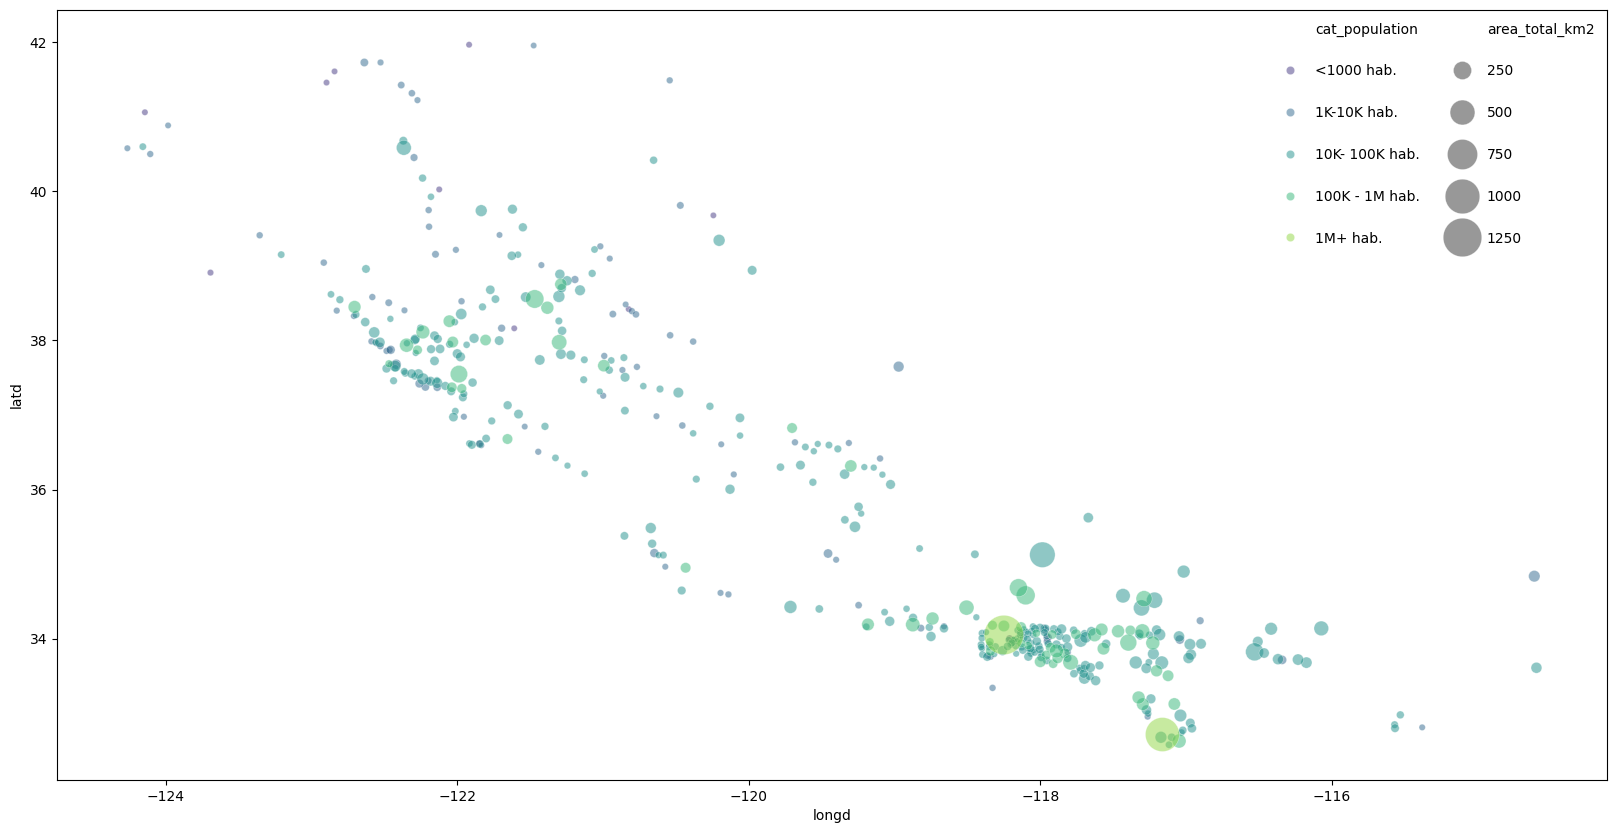

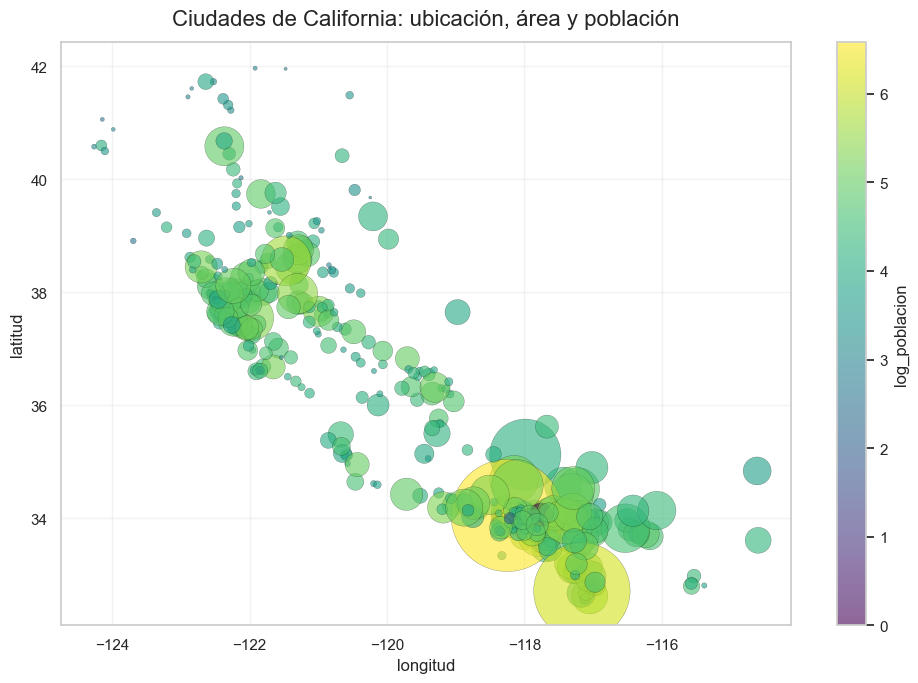

In [9]:
cities["log_poblacion"] = np.log10(cities["population_total"])

fig, ax = pintar_dispersion(
    cities,
    col_x="longd",
    col_y="latd",
    col_color="log_poblacion",
    tamano="area_total_km2",
    escala=5,
    mostrar_leyenda=True
)
ax.set_title("Ciudades de California: ubicación, área y población", fontsize=16, pad=12)
ax.set_xlabel("longitud")
ax.set_ylabel("latitud")
fig.savefig(FIG_DIR / "california_cities_scatter.png", dpi=160, bbox_inches="tight")
plt.show()

## #2: Presentación

En esta parte tendrás que hacer dos cosas, crear una presentación sobre el titanic de no más de 6 slides, sin incluir portada, con los siguientes mensajes y su apoyo en datos:  
1- El titanic fue un accidente con una tasa de mortalidad alta.  
2- En esa ocasión los datos apoyan que se dio el "Las mujeres y los niños primero", pero...  
3- ... que la clase en la que se viajes tuvo una influencia significativa y podría explicar...  
4- ... las diferencias de tasas de supervivencia entre mujeres y niños.    
5- Además aunque el puerto de embarque parece influir, se podría asumir que lo fue el tipo de pasaje que embarcó en cada uno.  

Y generar el notebook con las gráficas que vas a emplear en la presentación. Tienes que entregar ambas cosas.

Pasajeros registrados: 891


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,supervivencia,sexo,clase,puerto,grupo_edad
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,Fallece,Hombre,3ª clase,Southampton,Adulto/a
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,Sobrevive,Mujer,1ª clase,Cherbourg,Adulto/a
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,Sobrevive,Mujer,3ª clase,Southampton,Adulto/a
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,Sobrevive,Mujer,1ª clase,Southampton,Adulto/a
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,Fallece,Hombre,3ª clase,Southampton,Adulto/a


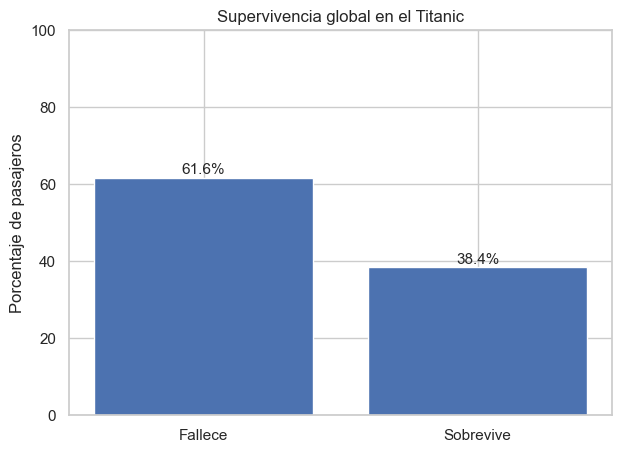

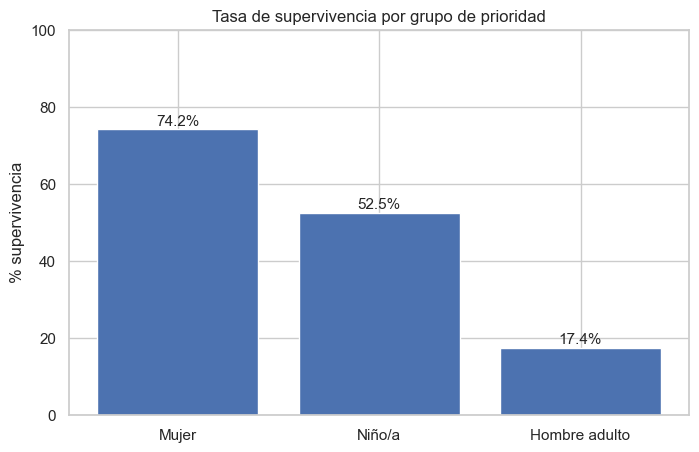

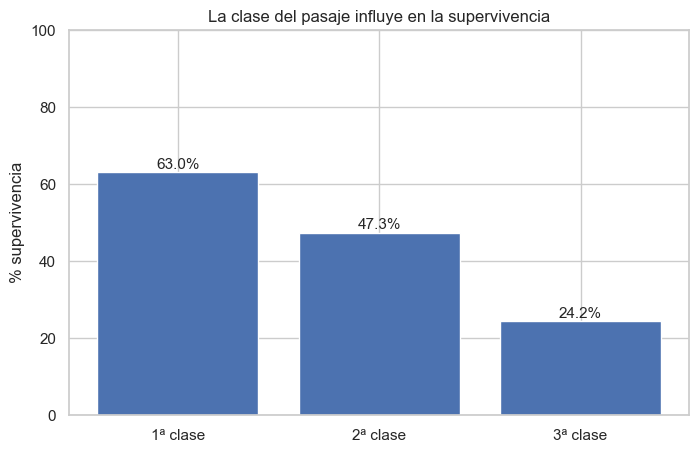

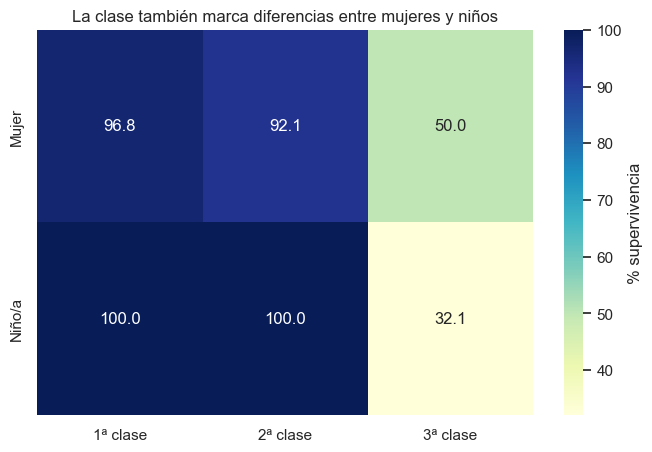

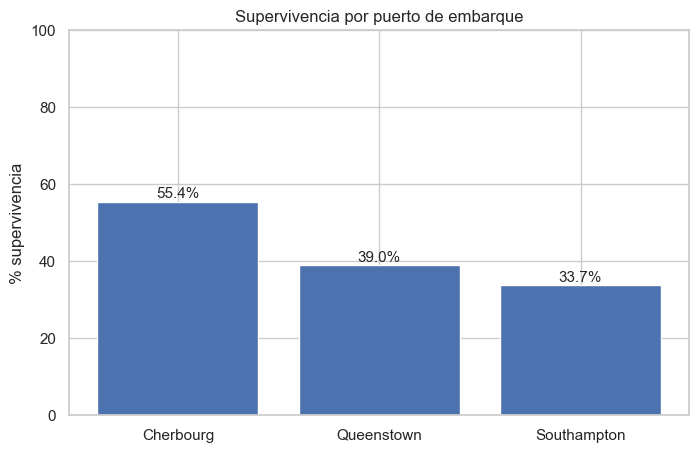

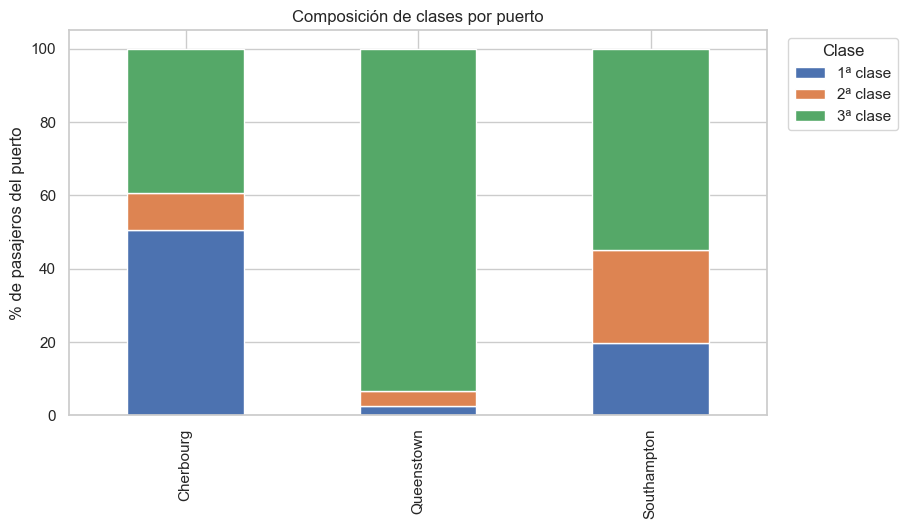

,Métrica,Valor
0,Mortalidad global,61.6%
1,Supervivencia mujeres,74.2%
2,Supervivencia niños/as,52.5%
3,Supervivencia hombres adultos,17.4%
4,Supervivencia 1ª clase,63.0%
5,Supervivencia 3ª clase,24.2%


In [10]:
# Cargamos el dataset de Titanic y preparamos variables útiles para las gráficas.
titanic_path = DATA_DIR / "titanic.csv"
titanic = pd.read_csv(titanic_path)

titanic = titanic.rename(columns=str.lower)
titanic["supervivencia"] = titanic["survived"].map({0: "Fallece", 1: "Sobrevive"})
titanic["sexo"] = titanic["sex"].map({"male": "Hombre", "female": "Mujer"})
titanic["clase"] = titanic["pclass"].map({1: "1ª clase", 2: "2ª clase", 3: "3ª clase"})
titanic["puerto"] = titanic["embarked"].map({"S": "Southampton", "C": "Cherbourg", "Q": "Queenstown"})
titanic["grupo_edad"] = np.where(titanic["age"].lt(16), "Niño/a", "Adulto/a")
titanic.loc[titanic["age"].isna(), "grupo_edad"] = np.nan

print(f"Pasajeros registrados: {len(titanic)}")
display(titanic.head())

def guardar_fig(fig, nombre):
    ruta = FIG_DIR / nombre
    fig.savefig(ruta, dpi=170, bbox_inches="tight")
    return ruta

# 1. Mortalidad global
mortality = titanic["supervivencia"].value_counts(normalize=True).mul(100).reindex(["Fallece", "Sobrevive"])
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(mortality.index, mortality.values)
ax.set_title("Supervivencia global en el Titanic")
ax.set_ylabel("Porcentaje de pasajeros")
ax.set_xlabel("")
for i, v in enumerate(mortality.values):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=11)
ax.set_ylim(0, 100)
guardar_fig(fig, "titanic_01_mortalidad_global.png")
plt.show()

# 2. Mujeres y niños primero
orden = ["Mujer", "Niño/a", "Hombre adulto"]
titanic["grupo_prioridad"] = np.select(
    [titanic["sexo"].eq("Mujer"), titanic["grupo_edad"].eq("Niño/a"), titanic["sexo"].eq("Hombre") & titanic["grupo_edad"].eq("Adulto/a")],
    ["Mujer", "Niño/a", "Hombre adulto"],
    default=None
)
prioridad = titanic.dropna(subset=["grupo_prioridad"]).groupby("grupo_prioridad")["survived"].mean().mul(100).reindex(orden)
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(prioridad.index, prioridad.values)
ax.set_title("Tasa de supervivencia por grupo de prioridad")
ax.set_ylabel("% supervivencia")
ax.set_xlabel("")
for i, v in enumerate(prioridad.values):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=11)
ax.set_ylim(0, 100)
guardar_fig(fig, "titanic_02_mujeres_ninos.png")
plt.show()

# 3. Influencia de la clase
clase_surv = titanic.groupby("clase")["survived"].mean().mul(100).reindex(["1ª clase", "2ª clase", "3ª clase"])
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(clase_surv.index, clase_surv.values)
ax.set_title("La clase del pasaje influye en la supervivencia")
ax.set_ylabel("% supervivencia")
ax.set_xlabel("")
for i, v in enumerate(clase_surv.values):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=11)
ax.set_ylim(0, 100)
guardar_fig(fig, "titanic_03_supervivencia_clase.png")
plt.show()

# 4. Mujeres y niños por clase
sub = titanic[titanic["grupo_prioridad"].isin(["Mujer", "Niño/a"])].dropna(subset=["clase"])
tabla = sub.pivot_table(index="grupo_prioridad", columns="clase", values="survived", aggfunc="mean").mul(100)
tabla = tabla[["1ª clase", "2ª clase", "3ª clase"]]
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(tabla, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={"label": "% supervivencia"}, ax=ax)
ax.set_title("La clase también marca diferencias entre mujeres y niños")
ax.set_xlabel("")
ax.set_ylabel("")
guardar_fig(fig, "titanic_04_mujeres_ninos_clase.png")
plt.show()

# 5. Puerto de embarque y composición de pasaje
puerto_surv = titanic.dropna(subset=["puerto"]).groupby("puerto")["survived"].mean().mul(100).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(puerto_surv.index, puerto_surv.values)
ax.set_title("Supervivencia por puerto de embarque")
ax.set_ylabel("% supervivencia")
ax.set_xlabel("")
for i, v in enumerate(puerto_surv.values):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=11)
ax.set_ylim(0, 100)
guardar_fig(fig, "titanic_05_supervivencia_puerto.png")
plt.show()

mix = pd.crosstab(titanic["puerto"], titanic["clase"], normalize="index").mul(100)[["1ª clase", "2ª clase", "3ª clase"]]
fig, ax = plt.subplots(figsize=(9, 5))
mix.plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Composición de clases por puerto")
ax.set_ylabel("% de pasajeros del puerto")
ax.set_xlabel("")
ax.legend(title="Clase", bbox_to_anchor=(1.02, 1), loc="upper left")
guardar_fig(fig, "titanic_06_mix_puerto_clase.png")
plt.show()

# Resumen numérico para apoyar la presentación
resumen = pd.DataFrame({
    "Métrica": [
        "Mortalidad global",
        "Supervivencia mujeres",
        "Supervivencia niños/as",
        "Supervivencia hombres adultos",
        "Supervivencia 1ª clase",
        "Supervivencia 3ª clase"
    ],
    "Valor": [
        100 - titanic["survived"].mean() * 100,
        prioridad.loc["Mujer"],
        prioridad.loc["Niño/a"],
        prioridad.loc["Hombre adulto"],
        clase_surv.loc["1ª clase"],
        clase_surv.loc["3ª clase"],
    ]
})
display(resumen.style.format({"Valor": "{:.1f}%"}))